### Predict energy and reactive atoms by computing Pipek-Mezey and rank atoms from PM populations

In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_useSVG=True

import py3Dmol

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np; np.random.seed(12345)
import torch; torch.manual_seed(12345)

from data import build_mol_from_xyz, qm9_splits
from model import training_run, validate, predict, calc_pm_populations, pm_atom_ranking

/home/cds/rketkaew/gitlab/mockingjay/scine_mockingjay/reactive_atom/model.py:425: SyntaxWarning: invalid escape sequence '\m'
  $s_A = \mathrm{agg}_i P_{iA}$,


In [3]:
from torch_geometric.datasets import QM9
ds = QM9(root="data/QM9")

In [4]:
ds[0]

Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1])

In [5]:
train, val, test = qm9_splits(ds, n_train=500, n_val=50, n_test=50, target="U0", shuffle=False, seed=42, subset=2000)

In [6]:
train[10]

{'Z': array([6, 6, 8, 1, 1, 1, 1], dtype=int32),
 'R': array([[-0.0029,  1.5099,  0.0087],
        [ 0.0261,  0.0033, -0.0375],
        [ 0.9423, -0.6551, -0.4568],
        [ 0.9228,  1.9263, -0.3915],
        [-0.862 ,  1.8785, -0.5648],
        [-0.1505,  1.8439,  1.0429],
        [-0.8944, -0.4864,  0.3577]], dtype=float32),
 'x': array([[6., 4., 4., 0., 0., 4.],
        [6., 3., 4., 0., 0., 4.],
        [8., 1., 2., 0., 0., 4.],
        [1., 1., 1., 0., 0., 1.],
        [1., 1., 1., 0., 0., 1.],
        [1., 1., 1., 0., 0., 1.],
        [1., 1., 1., 0., 0., 1.]], dtype=float32),
 'edge_index': array([[0, 1, 0, 3, 0, 4, 0, 5, 1, 2, 1, 6],
        [1, 0, 3, 0, 4, 0, 5, 0, 2, 1, 6, 1]]),
 'edge_attr': array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]], dtype=float32),
 'E': -4

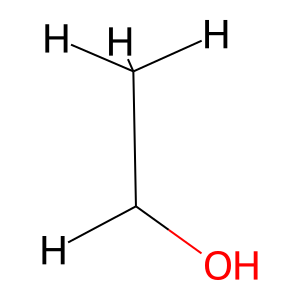

In [7]:
mol = train[10]
mol_3d, _ = build_mol_from_xyz(mol["Z"], mol["R"])
Draw.MolToImage(mol_3d)

In [8]:
def better_3dmol(molecule):
    mol = Chem.Mol(molecule)
    mol = AllChem.AddHs(mol, addCoords=True)
    AllChem.EmbedMolecule(mol)
    AllChem.MMFFOptimizeMolecule(mol)
    return mol

In [9]:
mol_3d = better_3dmol(mol_3d)

In [10]:
view = py3Dmol.view(
    width=300, height=300,
    data=Chem.MolToMolBlock(mol_3d),
    style={"stick": {}, "sphere": {"scale": 0.3}}
)
view.zoomTo()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

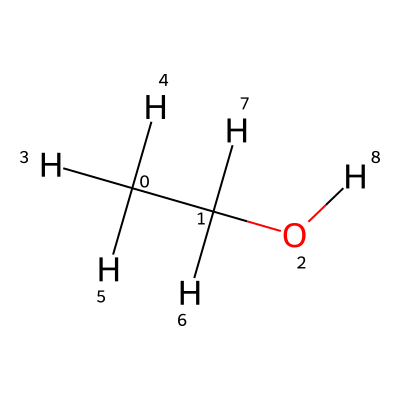

In [11]:
# Display 2D structure
mol = Chem.Mol(mol_3d)
AllChem.Compute2DCoords(mol)
dos = Draw.MolDrawOptions()
dos.addAtomIndices=True
Draw.MolToImage(mol, options=dos, size=(400, 400))

## Train model

In [12]:
config = {
    "model": "gat", # mpnn, gat, sage
    "hidden_dim": 64,
    "n_orb": 4,
    "loc_mode": "per_atom",
    "lr": 1e-3,
    "n_epochs": 5,
    "use_forces": False,
    "beta_init": 0.0,
    "beta_final": 1.0,
    "gamma": 0.1,
    "device": "cpu",
    "checkpoint_path": "best_ckpt.pt",
}

model, val_metrics = training_run(train, val, config)
print("Final validation metrics:", val_metrics)

Epoch   0 beta=0.0000 train_loss=8156186.500000 val_E_mae=1094.758076 time=2.3s
Epoch   1 beta=0.2000 train_loss=1415499.125000 val_E_mae=964.129023 time=2.3s
Epoch   2 beta=0.4000 train_loss=747567.437500 val_E_mae=658.434219 time=2.1s
Epoch   3 beta=0.6000 train_loss=503132.093750 val_E_mae=495.099287 time=2.5s
Epoch   4 beta=0.8000 train_loss=376638.187500 val_E_mae=695.042920 time=2.4s
Final validation metrics: {'E_mae': np.float64(495.099287109375)}


In [13]:
test_metrics = validate(
    model,
    test,
    config["device"]
)
print("Test metrics:", test_metrics)

Test metrics: {'E_mae': np.float64(400.6380078125)}


In [14]:
preds = predict(
    model,
    test,
    device=config["device"],
    reactive_mode="sum",
    threshold=None,
)

for i in range(min(2, len(preds))):
    print(f"Test[{i}] E_pred={preds[i]["E_pred"]:.6f}")
    print(f"  Full atom ranking: {preds[i]["reactive_indices"]}")

    Q_pm, J_pm = calc_pm_populations(list(test[i]["Z"]), test[i]["R"])
    pm_rank = pm_atom_ranking(Q_pm, mode="pm")
    print(f"  PM full atom ranking: {pm_rank}")

Test[0] E_pred=-8768.363281
  Full atom ranking: [7, 0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11]
  PM full atom ranking: [4, 0, 2, 1, 5, 3, 7, 6, 10, 8, 11, 9]
Test[1] E_pred=-7501.578125
  Full atom ranking: [0, 1, 10, 9, 4, 5, 2, 3, 7, 6, 8, 11, 12]
  PM full atom ranking: [0, 1, 3, 5, 4, 2, 8, 7, 9, 10, 6, 12, 11]
